In [68]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.13.0+cpu'

In [69]:
weights = 0.7
bias = 0.3

start = 0 
end = 1
step =0.02
x = torch.arange(start,end,step).unsqueeze(dim=1)
y = weights * x + bias

x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [70]:
train_split = int(0.8 * len(x))
X_train,Y_train = x[:train_split],y[:train_split]
X_test,Y_test = x[train_split:],y[train_split:]

len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

In [71]:
def plot_prediction(train_data = X_train,
                    train_label = Y_train,
                    test_data = X_test,
                    test_label = Y_test,
                    prediction = None):

    plt.Figure(figsize=(10,7))

    plt.scatter(train_data,train_label,c="b",s=4, label= "training data")
    plt.scatter(test_data,test_label,c="r",s=4, label= "testing data")
    
    if prediction is not None :
        plt.scatter(test_data,prediction,c="g",s=4, label= "training data")

    plt.legend(prop={"size": 8})

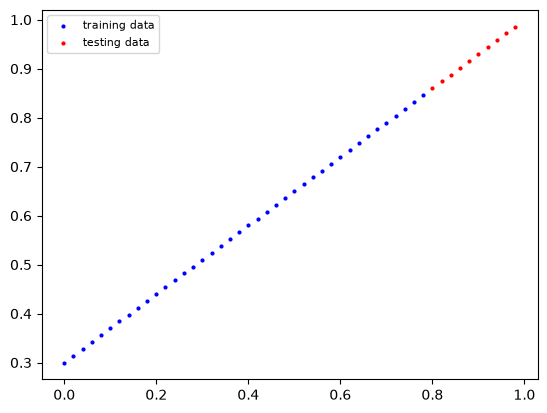

In [72]:
plot_prediction();

In [73]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                            requires_grad=True)
        
        
        self.bias = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                            requires_grad=True)
        
    def forward(self,X : torch.Tensor) -> torch.Tensor:
        return self.weights * X + self.bias


In [74]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [75]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [76]:
with torch.inference_mode():
    y_pred = model_0(X_test)

In [77]:
len(X_test),len(y_pred)


(10, 10)

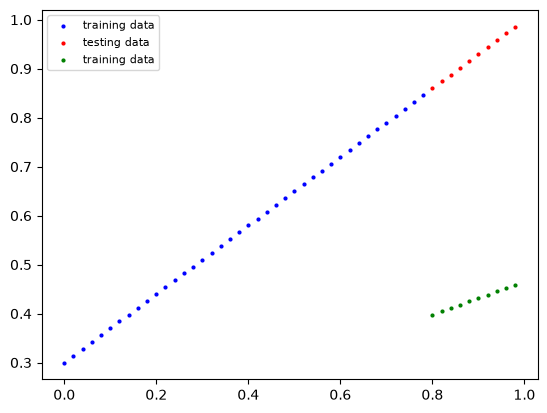

In [78]:
plot_prediction(prediction=y_pred)

In [79]:
loss_func = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [82]:
torch.manual_seed(42)

epochs =100

train_loss_value = []
test_loss_value = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_func(y_pred,Y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_func(test_pred,Y_test.type(torch.float))
        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_value.append(loss.detach().numpy())
            test_loss_value.append(test_loss.detach().numpy())
            print(f"E : {epoch} | MAE TRAIN LOSS : {loss} | MAE TEST LOSS : {test_loss}")


E : 0 | MAE TRAIN LOSS : 0.18615034222602844 | MAE TEST LOSS : 0.3328842222690582
E : 10 | MAE TRAIN LOSS : 0.08227583020925522 | MAE TEST LOSS : 0.2069590985774994
E : 20 | MAE TRAIN LOSS : 0.05181945487856865 | MAE TEST LOSS : 0.14023718237876892
E : 30 | MAE TRAIN LOSS : 0.04503796249628067 | MAE TEST LOSS : 0.11182951927185059
E : 40 | MAE TRAIN LOSS : 0.04132963344454765 | MAE TEST LOSS : 0.09809747338294983
E : 50 | MAE TRAIN LOSS : 0.03785243630409241 | MAE TEST LOSS : 0.08776430785655975
E : 60 | MAE TRAIN LOSS : 0.03441363573074341 | MAE TEST LOSS : 0.0794917643070221
E : 70 | MAE TRAIN LOSS : 0.030979642644524574 | MAE TEST LOSS : 0.07190609723329544
E : 80 | MAE TRAIN LOSS : 0.02754882536828518 | MAE TEST LOSS : 0.06363357603549957
E : 90 | MAE TRAIN LOSS : 0.024110013619065285 | MAE TEST LOSS : 0.05536102131009102


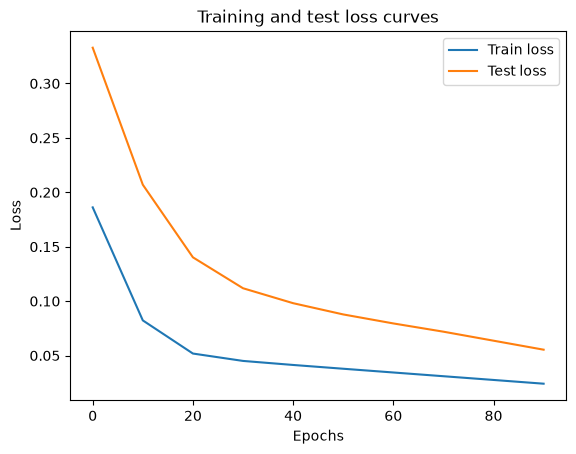

In [84]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_value, label="Train loss")
plt.plot(epoch_count, test_loss_value, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [86]:
model_0.state_dict(),weights,bias

(OrderedDict([('weights', tensor([0.5972])), ('bias', tensor([0.3433]))]),
 0.7,
 0.3)

In [87]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test)
y_pred


tensor([[0.8211],
        [0.8330],
        [0.8449],
        [0.8569],
        [0.8688],
        [0.8808],
        [0.8927],
        [0.9047],
        [0.9166],
        [0.9286]])

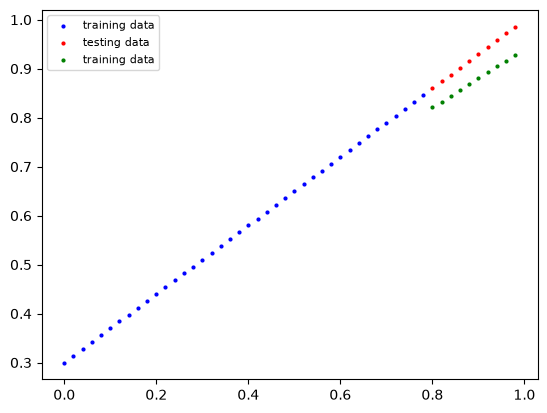

In [88]:
plot_prediction(prediction=y_pred)

In [ ]:
from pathlib import Path

model_path = Path("model")
